In [16]:
import wandb
import matplotlib as mpl
import matplotlib.pyplot as plt
import collections
import numpy as np
import pandas as pd

api = wandb.Api(timeout=39)

# Define your project and entity (replace with your specific values)
entity = "wang-kevin3290-princeton-university"  # e.g., your username or team name
project = "clean_JaxGCRL_test"


In [17]:
env_id = "humanoid_u_maze"
eval_env_id = None #"ant_u5_maze_eval"
env_title = "Arm Binpick Hard"
num_epochs = 100
metric = 'eval/episode_success'
metric_label = "Success"
valid_depths = [64, 256, 512]
valid_widths = [128, 256, 512, 1024, 2048, 4096]

filters = {
    "config.env_id": env_id,
    "config.eval_env_id": eval_env_id if eval_env_id else {"$in": ['', None, env_id]}, #{"$ne": "xxx"}, #
    "config.num_envs": 512,
    "config.num_sgd_batches_per_training_step": 800,
    "config.critic_network_width": 256,
    "config.batch_size": 512,
#     "config.num_epochs": {"$in": [num_epochs]}, #num_epochs,
    "config.disable_entropy": {"$ne": 1},
    "config.use_relu": {"$ne": 1},
    "config.resnet": "noishmistake4_nodense",
    "config.dropout": None,
    "config.logsumexp_penalty_coeff": {"$in": [None, 0.1]},
    "config.entropy_param": 0.5,
}

runs_api = api.runs(path=f"{entity}/{project}", filters=filters) #runs filtered by wandb api
len(runs_api)

342

In [18]:
# runs[0].summary

In [19]:
# for run in runs:
#     if run.config['num_epochs'] == 512:
#         break

In [20]:
# run.summary

In [21]:
# run.config

In [22]:
# run = runs[1]

In [23]:
# run.config

In [24]:
def get_avgs(runs_api, num_steps):
    #local filters
    runs = []
    dfs = {} #scratch space for arm_binpick_easy

    for run in runs_api:
        # check it actually has num_epoch steps completed
        if '_step' not in run.summary.keys():
            continue
            
        # check actor_depth == critic_depth and filter for valid_depths
        actor_depth = run.config['actor_depth']
        critic_depth = run.config['critic_depth']

        if actor_depth != critic_depth:
            continue
        if actor_depth not in valid_depths:
            continue

        runs.append(run)
    len(runs)
    
    depth_count = collections.defaultdict(int)
    for run in runs:
        depth_count[run.config['actor_depth']] += 1

    for d, c in depth_count.items():
        print(f"{d}: {c}")
        
    # Gather the raw metric curves by depth
    depth_curves = collections.defaultdict(list)

    for run in runs:
        depth = run.config['actor_depth']
        # Pull the full training history from W&B
        hist = run.history()
        if metric not in hist.columns:
            print(f"WARNING: metric not found in hist.columns for depth {depth} seed {run.config['seed']}, continuing...")
            continue
        values = hist[metric].values  # shape = (num_epochs,)
        if len(values) >= num_steps:  # Check if the curve has at least num_steps values
            depth_curves[depth].append(values[:num_steps])  # Truncate to num_steps

    print(f"completed part 1")

    # Now, for each depth, compute mean/std
    depth_mean = collections.defaultdict(list) # depth -> curve (mean)
    depth_std = collections.defaultdict(list)  # depth -> std
    for depth in valid_depths:
        curves = depth_curves[depth]
        print(f"{len(curves)} curves for depth {depth}")

        # Stack all runs for this depth: shape = (num_runs, num_steps)
        arr = np.stack(curves, axis=0)  # e.g. (N_runs, num_steps)
        mean_curve = arr.mean(axis=0)
        std_curve  = arr.std(axis=0) / np.sqrt(len(curves))
        assert len(curves) == arr.shape[0]
        depth_mean[depth] = mean_curve
        depth_std[depth] = std_curve
    return depth_mean, depth_std


In [25]:
def getRuns(env_id, env_title, metric, metric_label):
    
    filters = {
        "config.env_id": env_id,
        "config.eval_env_id": eval_env_id if eval_env_id else {"$in": ['', None, env_id]}, #{"$ne": "xxx"}, #
        "config.num_envs": 512,
        "config.num_sgd_batches_per_training_step": 800,
        "config.critic_network_width": 256,
        "config.batch_size": 512,
    #     "config.num_epochs": {"$in": [num_epochs]}, #num_epochs,
        "config.disable_entropy": {"$ne": 1},
        "config.use_relu": {"$ne": 1},
        "config.resnet": "noishmistake4_nodense",
        "config.dropout": None,
        "config.logsumexp_penalty_coeff": {"$in": [None, 0.1]},
        "config.entropy_param": 0.5,
    }

    runs_api = api.runs(path=f"{entity}/{project}", filters=filters) #runs filtered by wandb api
    return runs_api

In [26]:
allData = {}

In [27]:
env_id = "humanoid_u_maze"
env_title = env_id.replace("_", " ").title()
runs_api = getRuns(env_id, env_title, metric, metric_label)
print(len(runs_api))
#num_steps specifies how many steps to show on the x axis.
depth_mean, depth_std = get_avgs(runs_api, num_steps=150)

# Add data to allData
allData[env_id] = {
    "env_title": env_title,
    "num_epochs": num_epochs,
    "depth_mean": {depth: mean.tolist() for depth, mean in depth_mean.items()},
    "depth_std": {depth: std.tolist() for depth, std in depth_std.items()},
}


342
64: 106
256: 63
512: 5
completed part 1
106 curves for depth 64
63 curves for depth 256
2 curves for depth 512


In [29]:
env_id = "humanoid_big_maze"
env_title = env_id.replace("_", " ").title()
runs_api = getRuns(env_id, env_title, metric, metric_label)
print(len(runs_api))
depth_mean, depth_std = get_avgs(runs_api, num_steps=100)

# Add data to allData
allData[env_id] = {
    "env_title": env_title,
    "num_epochs": num_epochs,
    "depth_mean": {depth: mean.tolist() for depth, mean in depth_mean.items()},
    "depth_std": {depth: std.tolist() for depth, std in depth_std.items()},
}


237
64: 14
256: 9
512: 7
completed part 1
14 curves for depth 64
9 curves for depth 256
1 curves for depth 512


In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def plot_envs_subplots(allData, env_list, nrows, ncols, rc_params=None, figsize=(12, 7), colors=None, average_every=1, linewidth=2, horiz=None, padding=0.02, facts=[], depSize=20):
    # Update mpl.rcParams with provided rc_params, if any
    if rc_params:
        mpl.rcParams.update(rc_params)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs = axs.flatten()

    def downsample_curve(curve, step):
        return [np.mean(curve[i:i + step]) for i in range(0, len(curve), step)]

    def configure_axes(ax, is_last_row, is_first_col, title):
        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.set_title(title, pad=10)
        if is_last_row:
            ax.set_xlabel("Env step (M)", fontsize=19, labelpad=5)
        if is_first_col:
            ax.set_ylabel("Success")
        ax.grid(True, alpha=0.3)

    def style_spines(ax, color, width):
        for spine in ax.spines.values():
            spine.set_color(color)
            spine.set_linewidth(width)

    for i, env_id in enumerate(env_list):
        if env_id not in allData:
            print(f"Warning: {env_id} not found in allData")
            continue

        env_data = allData[env_id]
        env_title = env_data["env_title"]
        num_epochs = len(env_data["depth_mean"][list(env_data["depth_mean"].keys())[0]]) // average_every
        width_mean = env_data["depth_mean"]

        ax = axs[i]
        for j, (width, mean_curve) in enumerate(width_mean.items()):
            downsampled_mean = downsample_curve(mean_curve, average_every)
            color = colors[j % len(colors)] if colors else None
            ax.plot(np.arange(num_epochs) * average_every, downsampled_mean, label=f"{width}", color=color, linewidth=linewidth)

        if horiz:
            line1, line2 = horiz[2 * i], horiz[2 * i + 1]
            ax.axhline(y=line1, color='red', linestyle='--', linewidth=2.5)
            ax.axhline(y=line2, color='red', linestyle='--', linewidth=2.5)
            for line, label in zip([line1, line2], ["Depth 8", "Depth 16"]):
                ax.text(0, line + padding / 100 * ax.get_ylim()[1], label, color='red', weight='bold', fontsize=depSize, va='top', ha='left')

        configure_axes(ax, i // ncols == nrows - 1, i % ncols == 0, env_title)

    handles, labels = axs[0].get_legend_handles_labels()
    legend_handles = [mpl.lines.Line2D([], [], color=h.get_color(), linewidth=5) for h in handles]
    legend_handles.insert(0, mpl.lines.Line2D([], [], color='none'))
    labels.insert(0, "Depths:")

    for ax in axs:
        style_spines(ax, '#999999', 2)

    fig.legend(legend_handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
               ncol=len(labels), prop={'size': rc_params.get("legend.fontsize", 10), 'weight': 500}, columnspacing=1.7, borderpad=0.5)

    # Adjust subplot spacing
    plt.subplots_adjust(wspace=0.4, hspace=0.6)  # Increase spacing between subplots
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


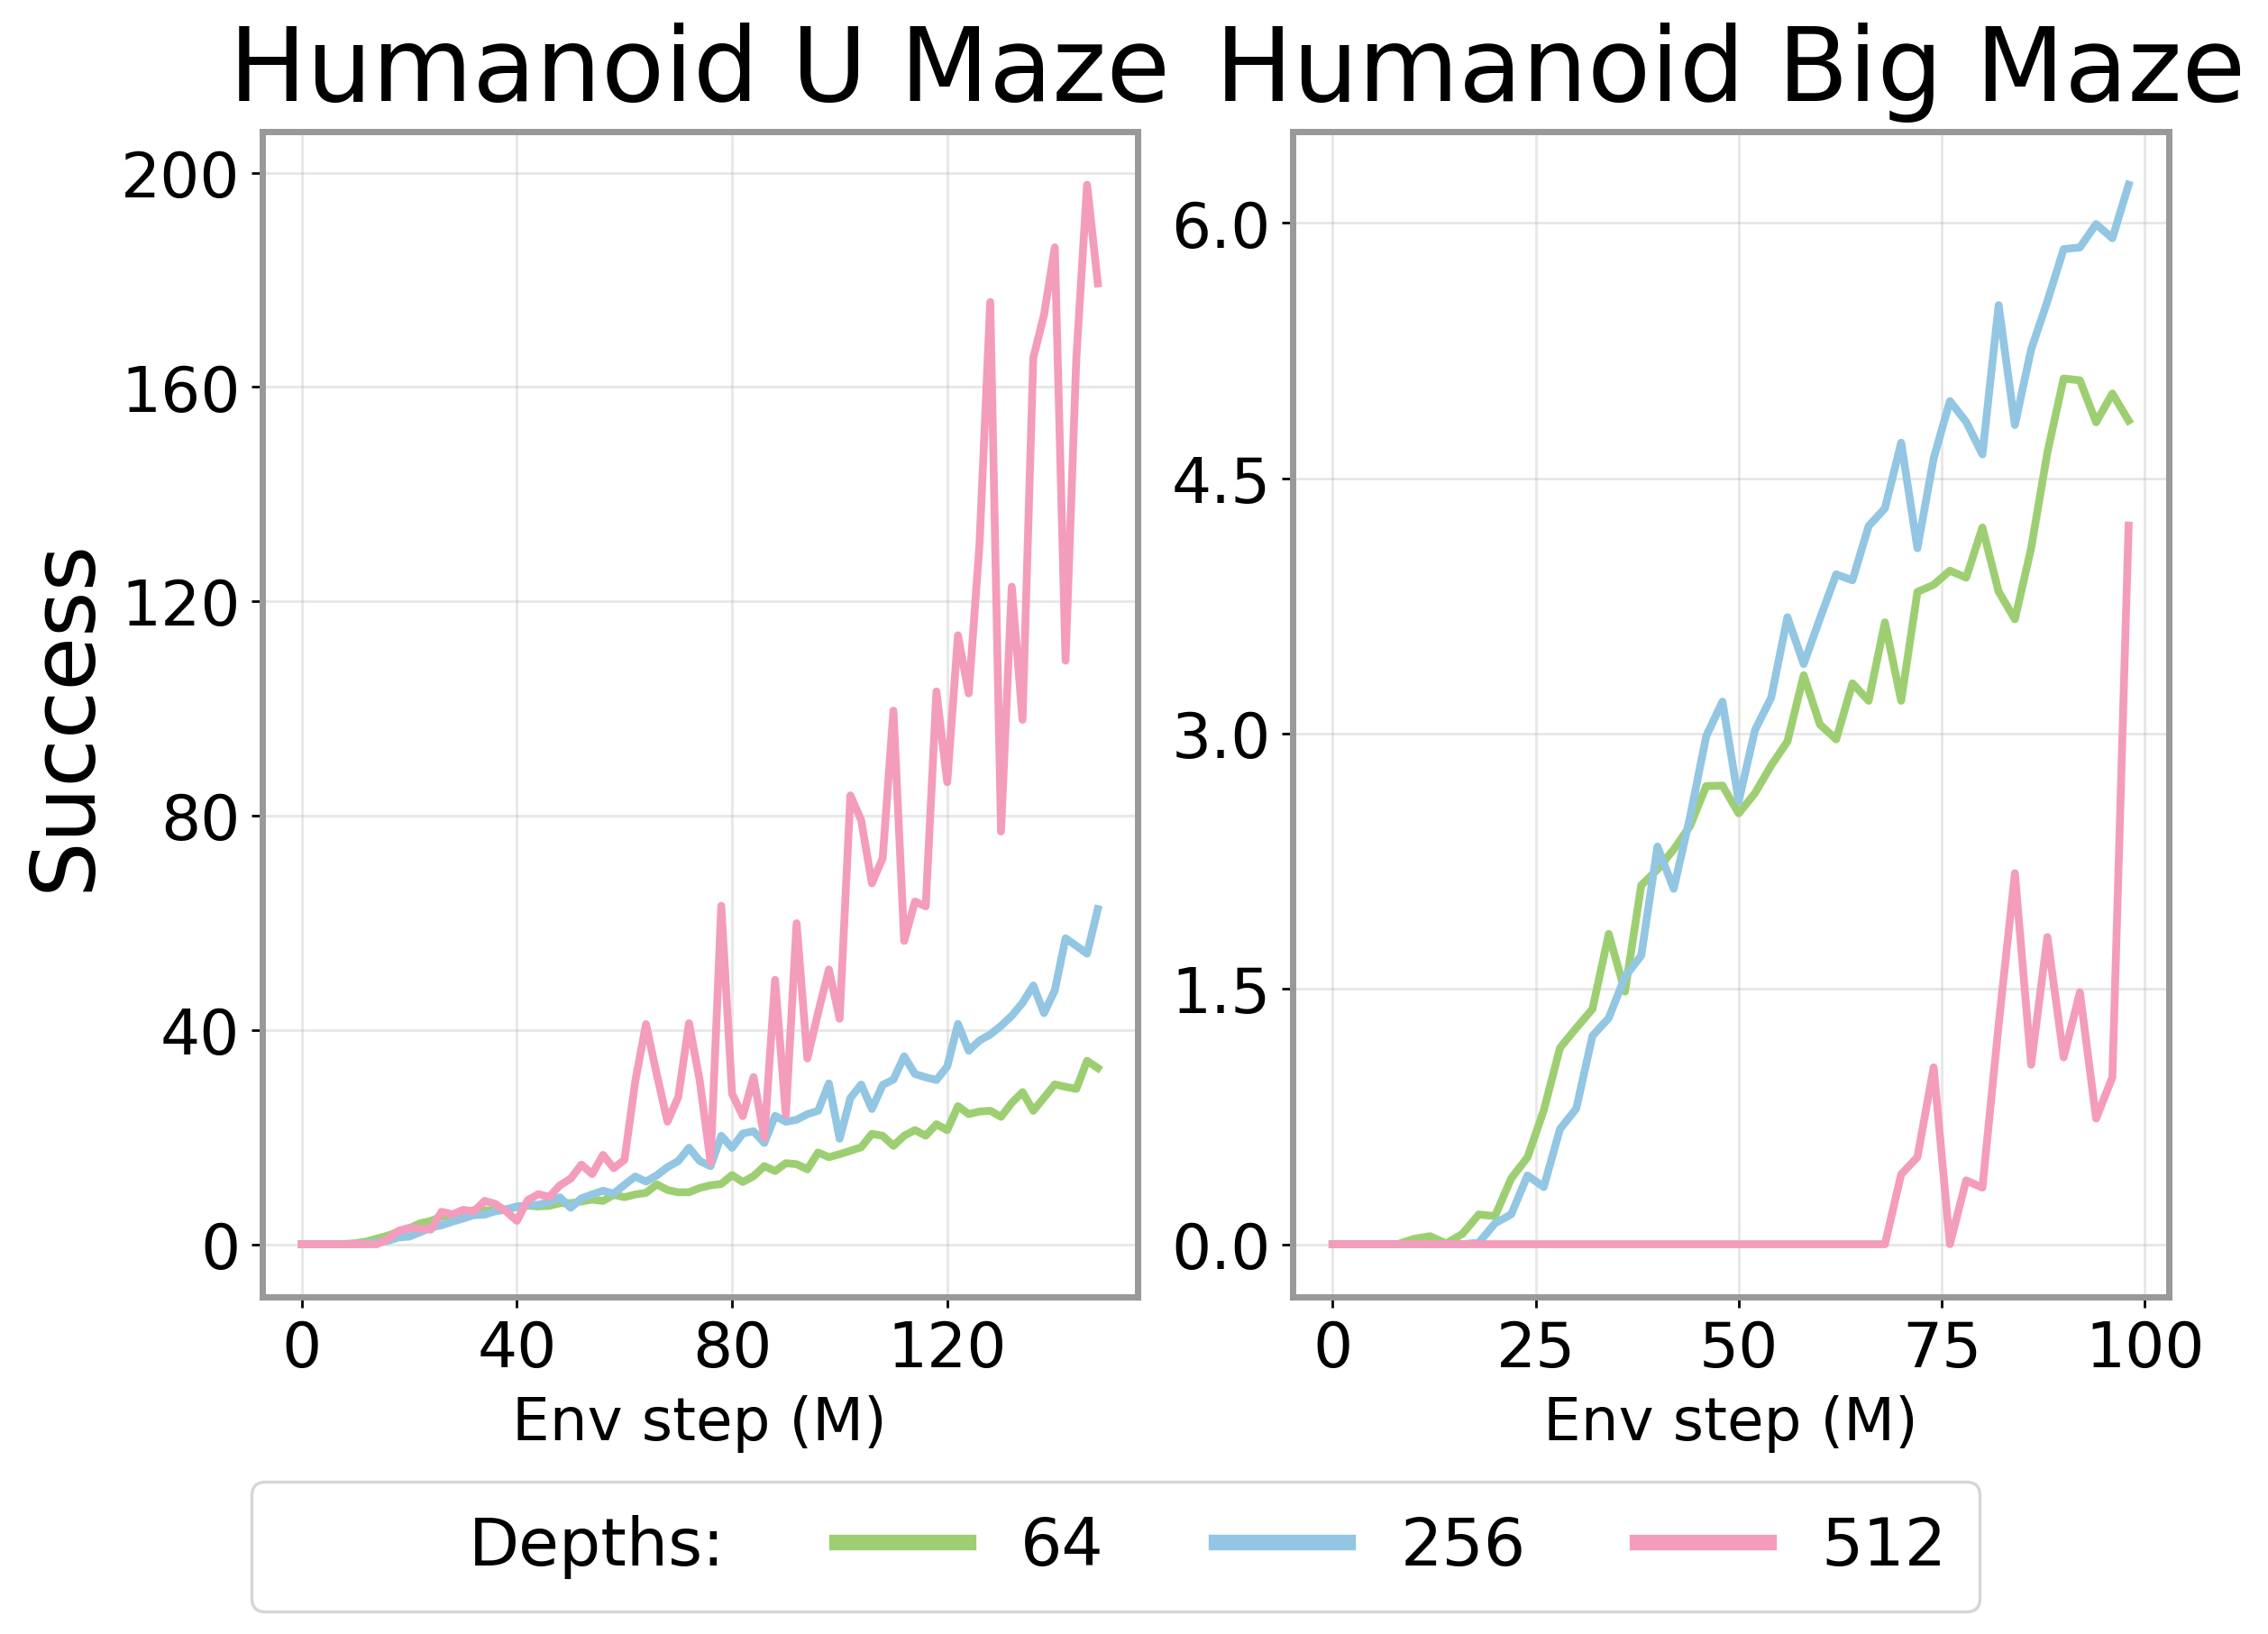

In [31]:
rc_params = {
    'figure.dpi': 250,
    'axes.titlesize': 33,
    'axes.labelsize': 28,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 21,
}

# Specify environments
env_list = ["humanoid_u_maze", "humanoid_big_maze"]

colors = ["brown", "purple", "orange", "blue", "green", "red"]
colors = ['#8c564b', '#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c', '#aaaaaa']
colors = ['#9dcf72', '#92c6e2', '#f49cbb']
# 92c6e2
# Call the function with the specified rcParams and figure size
plot_envs_subplots(allData, env_list, nrows=1, ncols=2, rc_params=rc_params, 
                   figsize=(10, 7), colors = colors, average_every = 2, 
                   linewidth=2.5, )


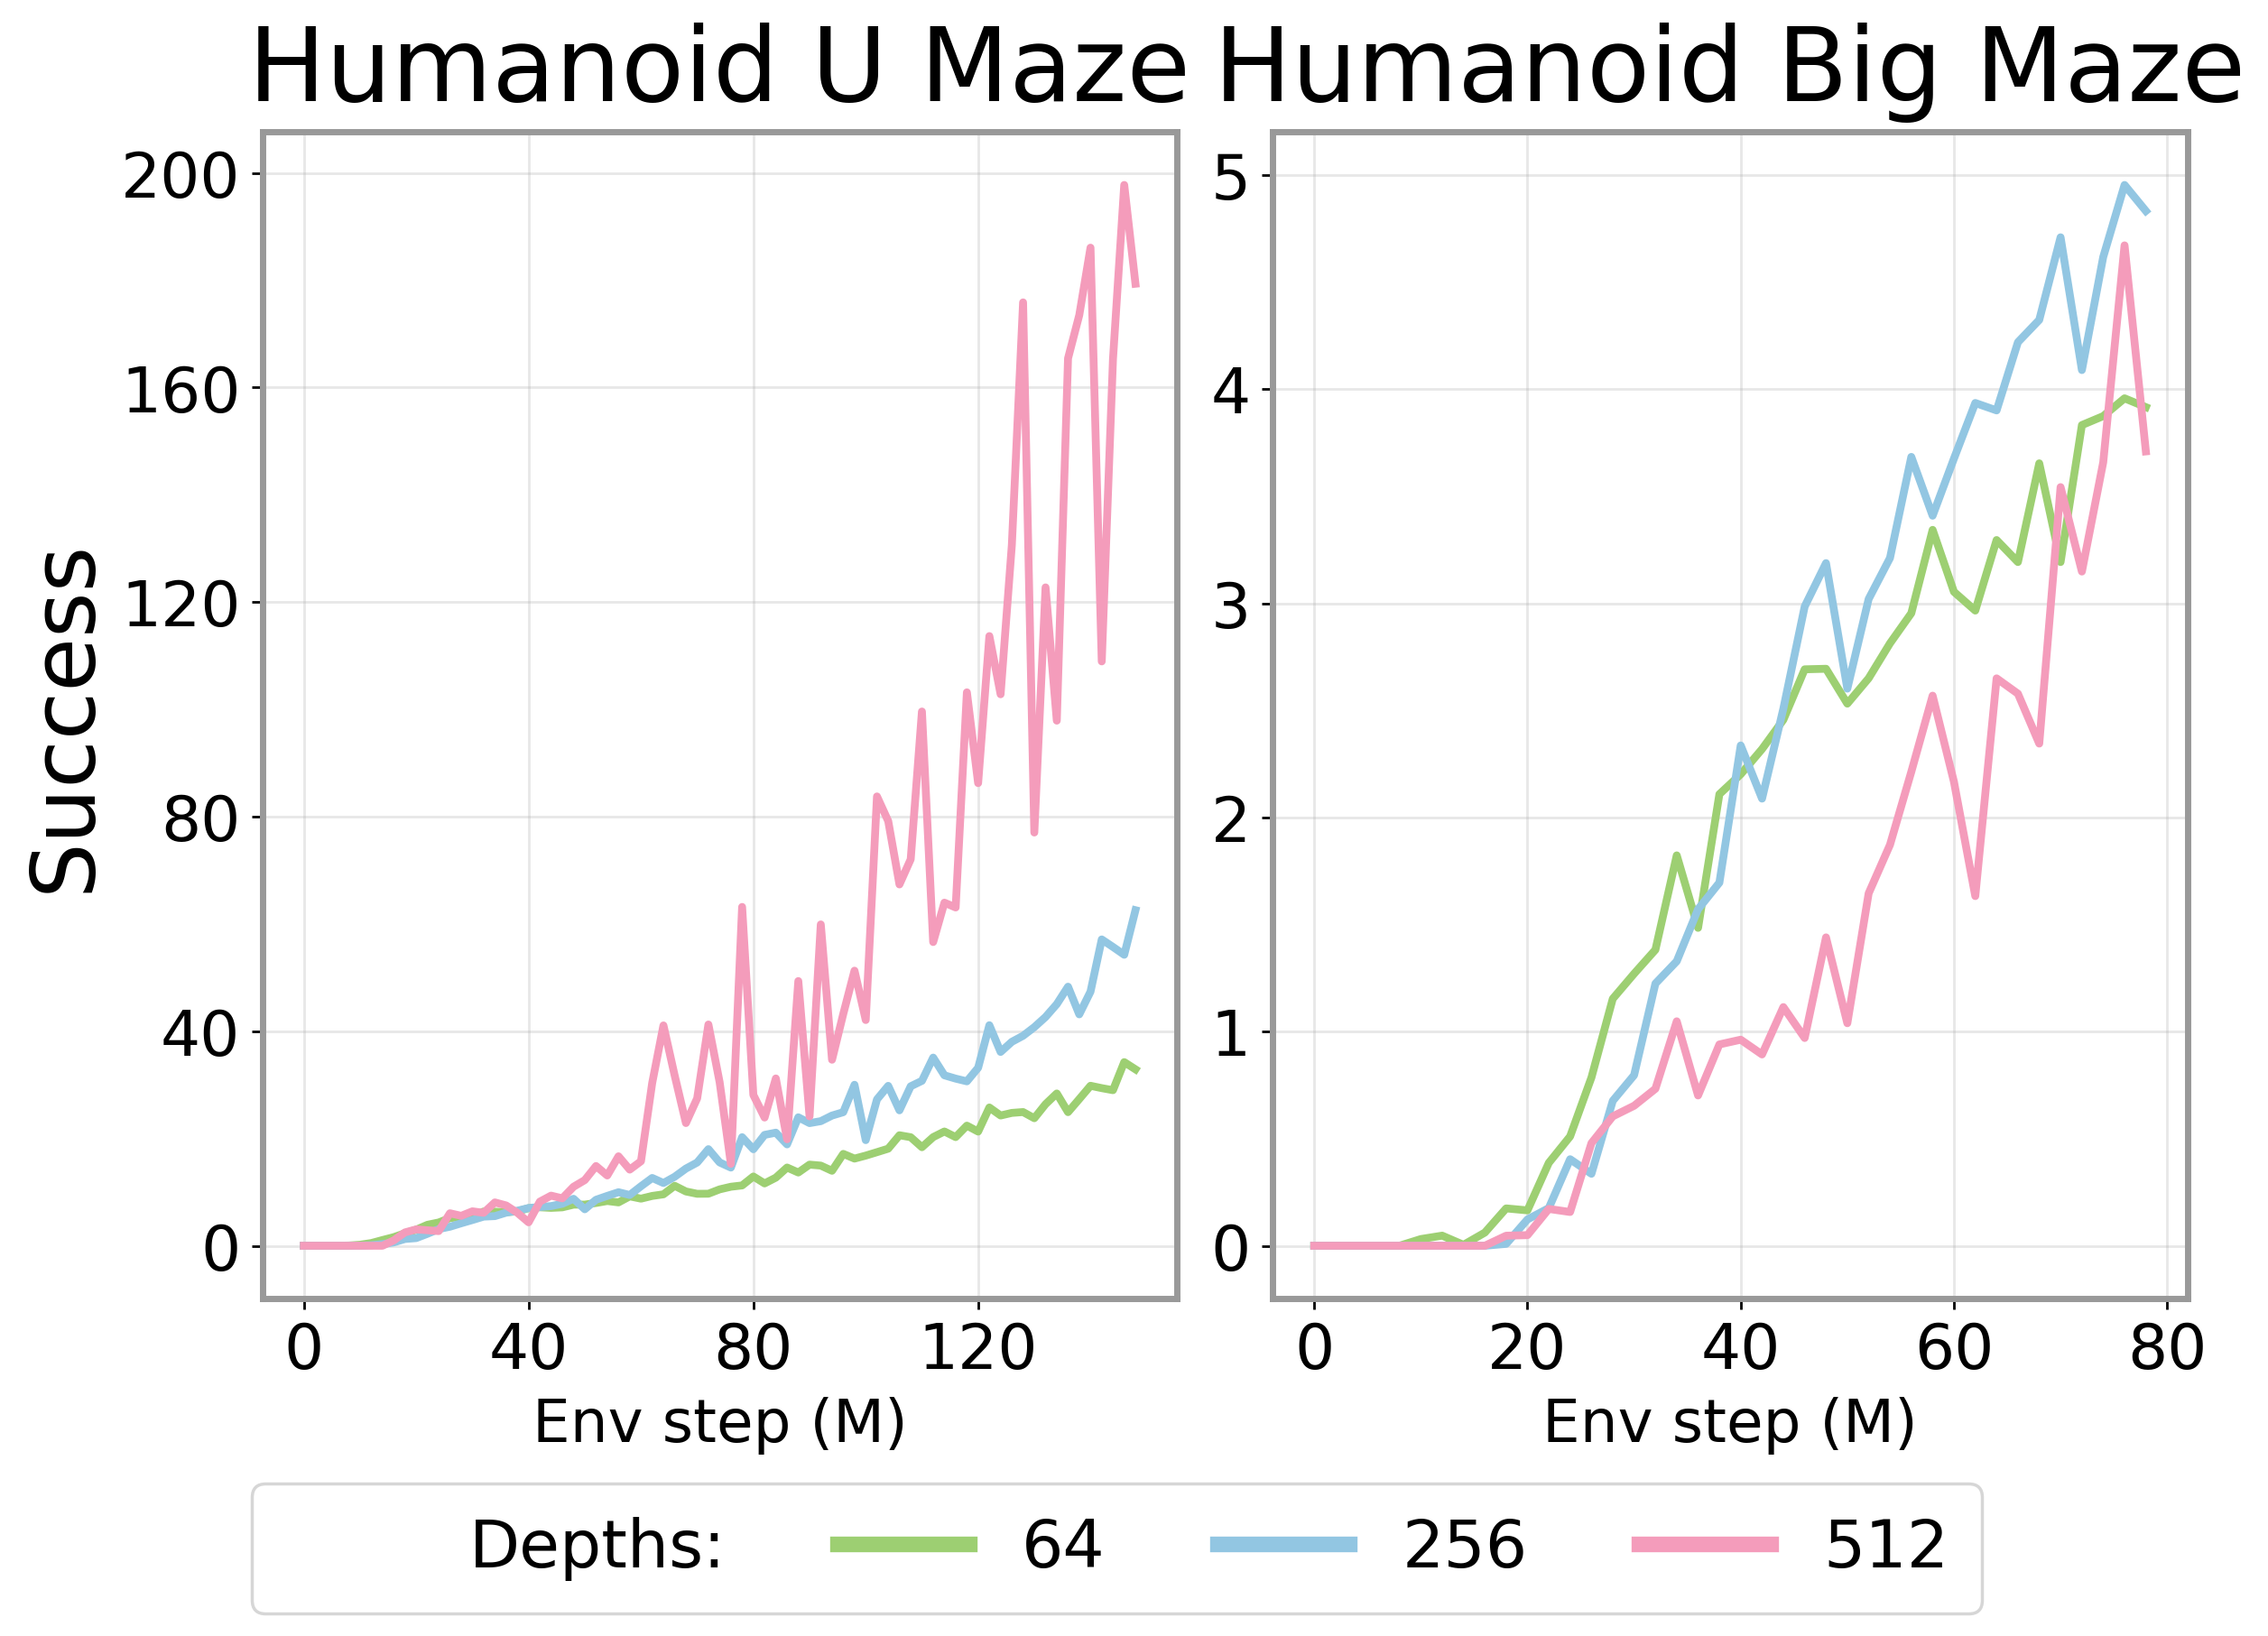

In [15]:
rc_params = {
    'figure.dpi': 250,
    'axes.titlesize': 33,
    'axes.labelsize': 28,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 21,
}

# Specify environments
env_list = ["humanoid_u_maze", "humanoid_big_maze"]

colors = ["brown", "purple", "orange", "blue", "green", "red"]
colors = ['#8c564b', '#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c', '#aaaaaa']
colors = ['#9dcf72', '#92c6e2', '#f49cbb']
# 92c6e2
# Call the function with the specified rcParams and figure size
plot_envs_subplots(allData, env_list, nrows=1, ncols=2, rc_params=rc_params, 
                   figsize=(10, 7), colors = colors, average_every = 2, 
                   linewidth=2.5, )
